# EEG Analysis 

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import mne

mne.set_log_level('WARNING')
%matplotlib inline

print(f'MNE version: {mne.__version__}')

MNE version: 1.12.0


Cargamos los 4 archivos `.fif` de cada sujeto :
- `loc_epo.fif`
- `locstim_epo.fif` 
- `main_epo.fif` 
- `mainstim_epo.fif` 

In [4]:
data_dir = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/'

# sujetos disponibles 
subjs_list = sorted([
    d for d in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, d)) and d.startswith('s')
])
print(f'Sujetos encontrados ({len(subjs_list)}): {subjs_list}')

Sujetos encontrados (28): ['s01', 's02', 's03', 's04', 's05', 's06', 's07', 's08', 's09', 's0x', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21', 's22', 's23', 's24', 's25', 's26', 's27']


In [5]:
# creamos listas vacías donde iremos guardando los datos de cada sujeto a medida que los cargamos

all_main_epochs   = []   
all_loc_epochs    = []  
all_locstim_epochs  = [] 
all_mainstim_epochs = [] 

all_main_rawdata    = []  
all_loc_rawdata     = []
all_locstim_rawdata = []
all_mainstim_rawdata = []

subjs_ok = []  # sujetos que se cargan correctamente

# para cada sujeto construimos las rutas completas a sus 4 archivos
for subject_id in subjs_list:
    subj_path = os.path.join(data_dir, subject_id)
    files = {
        'main':     os.path.join(subj_path, 'main_epo.fif'),
        'loc':      os.path.join(subj_path, 'loc_epo.fif'),
        'locstim':  os.path.join(subj_path, 'locstim_epo.fif'),
        'mainstim': os.path.join(subj_path, 'mainstim_epo.fif'),
    }
    
    # comprobamos que existen todos los archivos
    if not all(os.path.exists(f) for f in files.values()):
        print(f'{subject_id}: faltan archivos, se omite')
        continue
    
    try:
        main     = mne.read_epochs(files['main'],     preload=True, verbose=False)
        loc      = mne.read_epochs(files['loc'],      preload=True, verbose=False)
        locstim  = mne.read_epochs(files['locstim'],  preload=True, verbose=False)
        mainstim = mne.read_epochs(files['mainstim'], preload=True, verbose=False)
        
        all_main_epochs.append(main)
        all_loc_epochs.append(loc)
        all_locstim_epochs.append(locstim)
        all_mainstim_epochs.append(mainstim)
        
        all_main_rawdata.append({
            'epoch_dat': main.get_data(), 'metadata': main.metadata})
        all_loc_rawdata.append({
            'epoch_dat': loc.get_data(),  'metadata': loc.metadata})
        all_locstim_rawdata.append({
            'epoch_dat': locstim.get_data(), 'metadata': locstim.metadata})
        all_mainstim_rawdata.append({
            'epoch_dat': mainstim.get_data(), 'metadata': mainstim.metadata})
        
        subjs_ok.append(subject_id)
        print(f'{subject_id} cargado — main: {main.get_data().shape}, '
              f'loc: {loc.get_data().shape}, '
              f'locstim: {locstim.get_data().shape}')
    except Exception as e:
        print(f'{subject_id}: error al cargar → {e}')

nSubj = len(subjs_ok)
print(f'\ntotal sujetos cargados: {nSubj}')

# (número de trials,  número de canales,  número de timepoints)


s01 cargado — main: (250, 32, 2876), loc: (150, 32, 2876), locstim: (954, 32, 201)
s02 cargado — main: (261, 32, 2876), loc: (156, 32, 2876), locstim: (913, 32, 201)
s03 cargado — main: (256, 32, 2876), loc: (146, 32, 2876), locstim: (935, 32, 201)
s04 cargado — main: (236, 32, 2876), loc: (121, 32, 2876), locstim: (795, 32, 201)
s05 cargado — main: (243, 32, 2876), loc: (150, 32, 2876), locstim: (920, 32, 201)
s06: faltan archivos, se omite
s07 cargado — main: (249, 32, 2876), loc: (156, 32, 2876), locstim: (859, 32, 201)
s08 cargado — main: (247, 32, 2876), loc: (143, 32, 2876), locstim: (896, 32, 201)
s09 cargado — main: (193, 32, 2876), loc: (153, 32, 2876), locstim: (936, 32, 201)
s0x: faltan archivos, se omite
s10 cargado — main: (250, 32, 2876), loc: (153, 32, 2876), locstim: (787, 32, 201)
s11 cargado — main: (251, 32, 2876), loc: (147, 32, 2876), locstim: (699, 32, 201)
s12 cargado — main: (252, 32, 2876), loc: (141, 32, 2876), locstim: (792, 32, 201)
s13 cargado — main: (253,

## Grand Average
Ploteamos la media de todos los trials de todos los sujetos.
Las líneas verticales indican:
- Azul : inicio del trial (t=0)
- Verde : onset de cada uno de los 6 estímulos
- Rojo : inicio y fin de la secuencia de estímulos

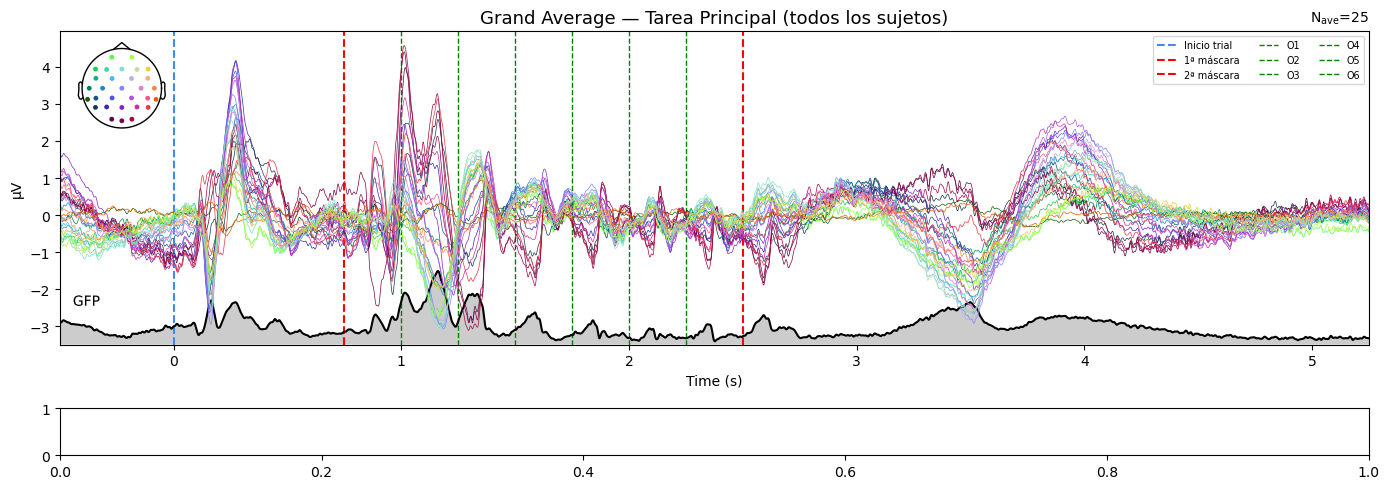

In [6]:

main_evokeds = [ep.average() for ep in all_main_epochs] # para cada sujeto calculamos la media de todos sus trials = ERP
main_gaverage = mne.grand_average(main_evokeds) # promedia los ERPs de los 25 sujetos entre si = GRAND AVERAGE

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 5),
                         gridspec_kw=dict(height_ratios=[5, 0.75]))

main_gaverage.plot(axes=axes[0], spatial_colors=True, gfp=True, show=False)
axes[0].set_title('Grand Average — Tarea Principal (todos los sujetos)', fontsize=13)

# añadimos las lineas temporales: onset de cada estímulo (máscara + 6 estímulos + máscara)
# máscara t=0.75s, estímulos cada 0.25s
axes[0].axvline(0,                    color='#4488EE', ls='--', lw=1.5, label='Inicio trial')
axes[0].axvline(0.75,                 color='red',     ls='--', lw=1.5, label='1ª máscara')
axes[0].axvline(0.75 + 0.25 * 7,     color='red',     ls='--', lw=1.5, label='2ª máscara')
for istim in range(6):
    t = 0.75 + 0.25 * (istim + 1)
    axes[0].axvline(t, color='green', ls='--', lw=1, 
                    label=f'O{istim+1}' if istim == 0 else f'O{istim+1}')

axes[0].legend(loc='upper right', fontsize=7, ncol=3)
plt.tight_layout()
plt.show()

## Canal occipital (Oz) separado por nrep

Queremos ver si la amplitud de la respuesta occipital va **disminuyendo** a medida que el trial se repite (nrep 0 → 1 → 2) que seria la prueba del sesgo de confirmación a nivel neural

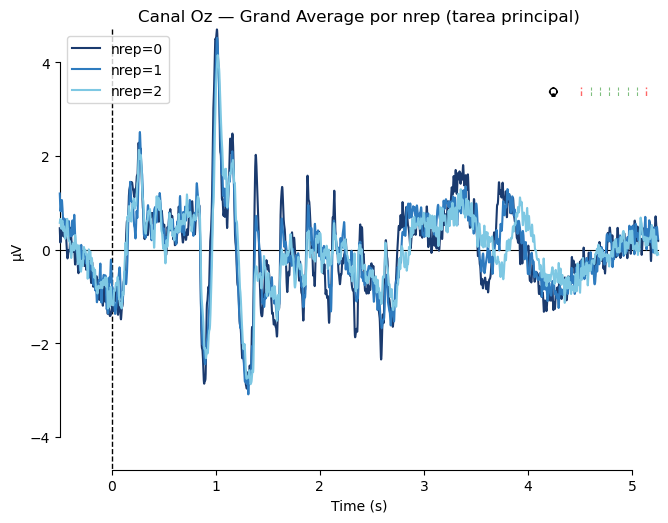

In [7]:
# grand average por nrep 
nreps = [0, 1, 2]
colors_nrep = ['#1a3a6e', '#2e7bbf', '#7ec8e3']  # azul oscuro → azul clarito

# para cada nrep, calculamos la media de cada sujeto y luego el grand average
# es decir, para cada nrep, para cada sujeto, coge los trials correspondientes a ese nrep, calcula su media (ERP) y luego promedia entre sujetos (grand average)
rep_gaverage = []
for irep in nreps:
    evoks_irep = []
    for isubj in range(nSubj):
        epoch = all_main_epochs[isubj]
        mdata = epoch.metadata.copy().reset_index(drop=True)
        sel_idx = mdata[mdata['nrep'] == irep].index
        if len(sel_idx) > 0:
            evoks_irep.append(epoch[sel_idx].average())
    if evoks_irep:
        rep_gaverage.append(mne.grand_average(evoks_irep))
    else:
        rep_gaverage.append(None)

# plot_compare_evokeds es una funcion de MNE que plotea varios ERPs juntos para compararlos. 
# le pasamos los 3 grand averages y le decimos picks=['Oz'] para que solo muestre el canal Oz (el occipital central, el mas relevante para ver la respuesta visual)
evokeds_dict = {
    f'nrep={irep}': rep_gaverage[irep]
    for irep in nreps if rep_gaverage[irep] is not None
}

fig = mne.viz.plot_compare_evokeds(
    evokeds_dict,
    picks=['Oz'],
    colors=colors_nrep[:len(evokeds_dict)],
    title='Canal Oz — Grand Average por nrep (tarea principal)',
    show=False
)

# Añadimos líneas de onset de estímulos
ax = plt.gca()
ax.axvline(0.75,             color='red',   ls='--', lw=1, alpha=0.6)
ax.axvline(0.75 + 0.25 * 7, color='red',   ls='--', lw=1, alpha=0.6)
for istim in range(6):
    ax.axvline(0.75 + 0.25 * (istim + 1), color='green', ls='--', lw=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

## Grand Average del localizador

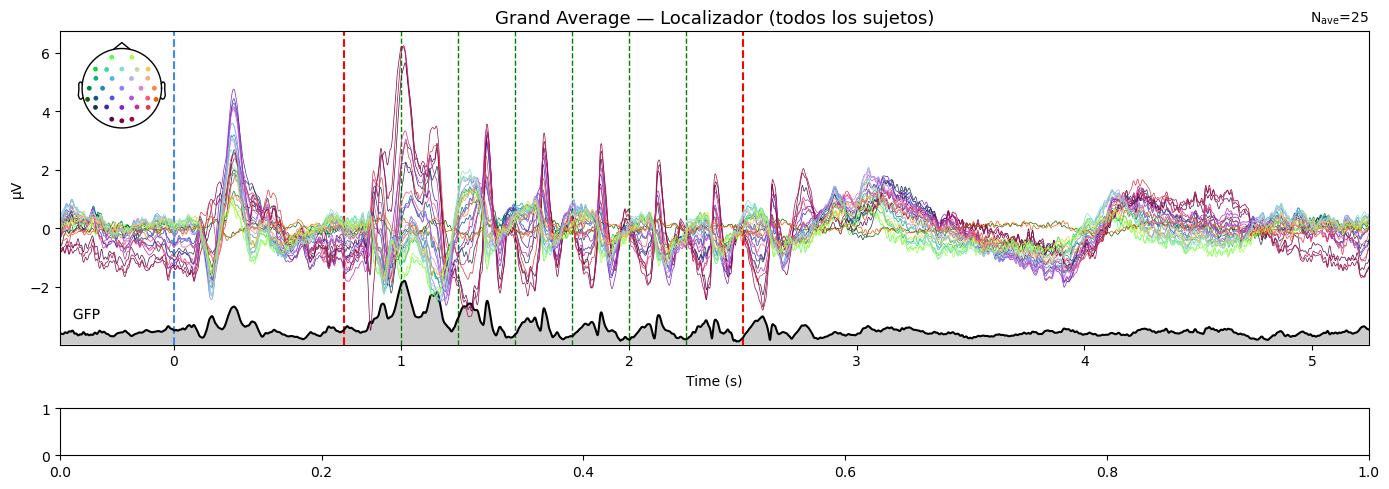

In [8]:
# grand average localizador 
loc_evokeds  = [ep.average() for ep in all_loc_epochs]
loc_gaverage = mne.grand_average(loc_evokeds)

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 5),
                         gridspec_kw=dict(height_ratios=[5, 0.75]))

loc_gaverage.plot(axes=axes[0], spatial_colors=True, gfp=True, show=False)
axes[0].set_title('Grand Average — Localizador (todos los sujetos)', fontsize=13)

axes[0].axvline(0,                color='#4488EE', ls='--', lw=1.5)
axes[0].axvline(0.75,             color='red',     ls='--', lw=1.5)
axes[0].axvline(0.75 + 0.25 * 7, color='red',     ls='--', lw=1.5)
for istim in range(6):
    axes[0].axvline(0.75 + 0.25 * (istim + 1), color='green', ls='--', lw=1)

plt.tight_layout()
plt.show()

## piquitos del locstim
cada "trial" en `locstim_epo` es un estímulo individual del localizador 
--> por ejemplo s01 tiene 954 de estos trials (≈ 150 trials × 6 estímulos)

la ventana es muy pequeña (−0.1s a +0.3s)

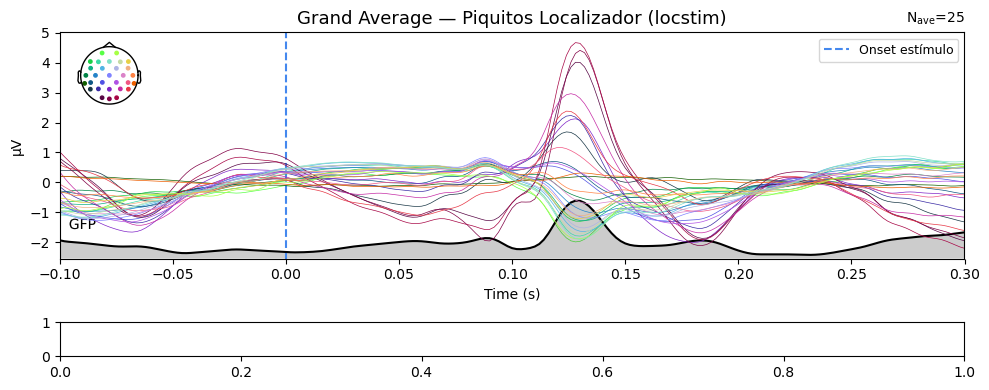

In [9]:
# grand average locstim (piquitos del localizador) 
locstim_evokeds  = [ep.average() for ep in all_locstim_epochs]
locstim_gaverage = mne.grand_average(locstim_evokeds)

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 4),
                         gridspec_kw=dict(height_ratios=[5, 0.75]))

locstim_gaverage.plot(axes=axes[0], spatial_colors=True, gfp=True, show=False)
axes[0].set_title('Grand Average — Piquitos Localizador (locstim)', fontsize=13)
axes[0].axvline(0, color='#4488EE', ls='--', lw=1.5, label='Onset estímulo')
axes[0].legend(fontsize=9)

plt.tight_layout()
plt.show()

## resumen de los datos cargados

In [10]:
header = f"{'Sujeto':<8} {'main':>22} {'loc':>22} {'locstim':>22} {'mainstim':>22}"
print(header)
print('-' * 80)
for i, subj in enumerate(subjs_ok):
    sh_main     = all_main_rawdata[i]['epoch_dat'].shape
    sh_loc      = all_loc_rawdata[i]['epoch_dat'].shape
    sh_locstim  = all_locstim_rawdata[i]['epoch_dat'].shape
    sh_mainstim = all_mainstim_rawdata[i]['epoch_dat'].shape
    print(f"{subj:<8} {str(sh_main):>22} {str(sh_loc):>22} {str(sh_locstim):>22} {str(sh_mainstim):>22}")

print(f"\nDimensiones: (trials x canales x timepoints)")
print(f"Sfreq: {all_main_epochs[0].info['sfreq']} Hz")
print(f"Canales: {len(all_main_epochs[0].ch_names)}")
print(f"Ventana main/loc: {all_main_epochs[0].tmin:.2f}s -> {all_main_epochs[0].tmax:.2f}s")
print(f"Ventana locstim:  {all_locstim_epochs[0].tmin:.2f}s -> {all_locstim_epochs[0].tmax:.2f}s")

Sujeto                     main                    loc                locstim               mainstim
--------------------------------------------------------------------------------
s01             (250, 32, 2876)        (150, 32, 2876)         (954, 32, 201)        (1563, 32, 201)
s02             (261, 32, 2876)        (156, 32, 2876)         (913, 32, 201)        (261, 32, 2876)
s03             (256, 32, 2876)        (146, 32, 2876)         (935, 32, 201)        (256, 32, 2876)
s04             (236, 32, 2876)        (121, 32, 2876)         (795, 32, 201)        (1415, 32, 201)
s05             (243, 32, 2876)        (150, 32, 2876)         (920, 32, 201)        (243, 32, 2876)
s07             (249, 32, 2876)        (156, 32, 2876)         (859, 32, 201)        (249, 32, 2876)
s08             (247, 32, 2876)        (143, 32, 2876)         (896, 32, 201)        (247, 32, 2876)
s09             (193, 32, 2876)        (153, 32, 2876)         (936, 32, 201)        (193, 32, 2876)
s10       

---
## clasificador — decoding punto a punto

para cada estímulo Oi y cada timepoint t, queremos entrenar un clasificador que prediga
la orientación del estímulo a partir de la actividad de los 32 canales en ese instante

### funciones auxiliares 

In [11]:
# definimos funciones auxiliares para el decoding que usara el clasificador mas adelante

import numpy as np
from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.model_selection import StratifiedKFold
import time as tm

# AngularRegression --> usamos un clasificador que aprende a predecir un numero a partir de features --> PROBLEMA 
# las orientaciones son circulares, es decir, 0° y 180° son iguales en gratings, entonces no podemos predecir el ángulo directamente con una regresión lineal porque el modelo no entendería que 0° y 180° son lo mismo
# lo que hacemos es convertir el angulo en 2 componentes que si que son lineales --> cos(2θ) y sin(2θ) por separado
# y luego los combinamoa para recuperar el ángulo origina
class AngularRegression(BaseEstimator, RegressorMixin):
    def __init__(self, clf=None):
        self.clf = clf if clf is not None else LinearSVR()

    def fit(self, X, y):
        # y son orientaciones en radianes
        # multiplicamos por 2 para que 0° y 180° sean equivalentes
        self.clf_cos = clone(self.clf)
        self.clf_sin = clone(self.clf)
        self.clf_cos.fit(X, np.cos(2 * y))
        self.clf_sin.fit(X, np.sin(2 * y))
        return self

    def predict(self, X):
        cos_pred = self.clf_cos.predict(X)
        sin_pred = self.clf_sin.predict(X)
        # recuperamos el ángulo y dividimos por 2 para volver al espacio original
        return np.arctan2(sin_pred, cos_pred) / 2


# scorer_angle --> mide que tan bien predijo el clasificador la orientacion
# usa la correlación circular: calcula el error entre orientación real y la predicha
# Resultado entre -1 y 1 : 0 = azar, 1 = perfecto.
def scorer_angle(y_true, y_pred):
    error = 2 * y_true - 2 * y_pred
    return np.mean(np.cos(error))


#  CreateFolds --> crea 5 folds estratificados: cada fold tiene trials de todas las orientaciones
def create_folds(y_binned, n_folds=5):
   
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    folds = []
    dummy_X = np.zeros(len(y_binned))
    for train_idx, test_idx in skf.split(dummy_X, y_binned):
        folds.append({'train_index': train_idx, 'test_index': test_idx})
    return folds

print('funciones auxiliares definidas: AngularRegression, scorer_angle, create_folds')

funciones auxiliares definidas: AngularRegression, scorer_angle, create_folds


### decoding punto a punto — loop sobre sujetos y estímulos


── Sujeto s01 (1/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 4.1 min transcurridos

── Sujeto s02 (2/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 8.7 min transcurridos

── Sujeto s03 (3/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 12.8 min transcurridos

── Sujeto s04 (4/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 16.8 min transcurridos

── Sujeto s05 (5/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 20.9 min transcurridos

── Sujeto s07 (6/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 25.1 min transcurridos

── Sujeto s08 (7/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 29.3 min transcurridos

── Sujeto s09 (8/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 32.9 min transcurridos

── Sujeto s10 (9/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 36.9 min transcurridos

── Sujeto s11 (10/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 39.9 min transcurridos

── Sujeto s12 (11/25) ──
  O1 ✓  O2 ✓  O3 ✓  O4 ✓  O5 ✓  O6 ✓  → 43.0 min transcurridos

── Sujeto s13 (12/25) ──
  O1 ✓

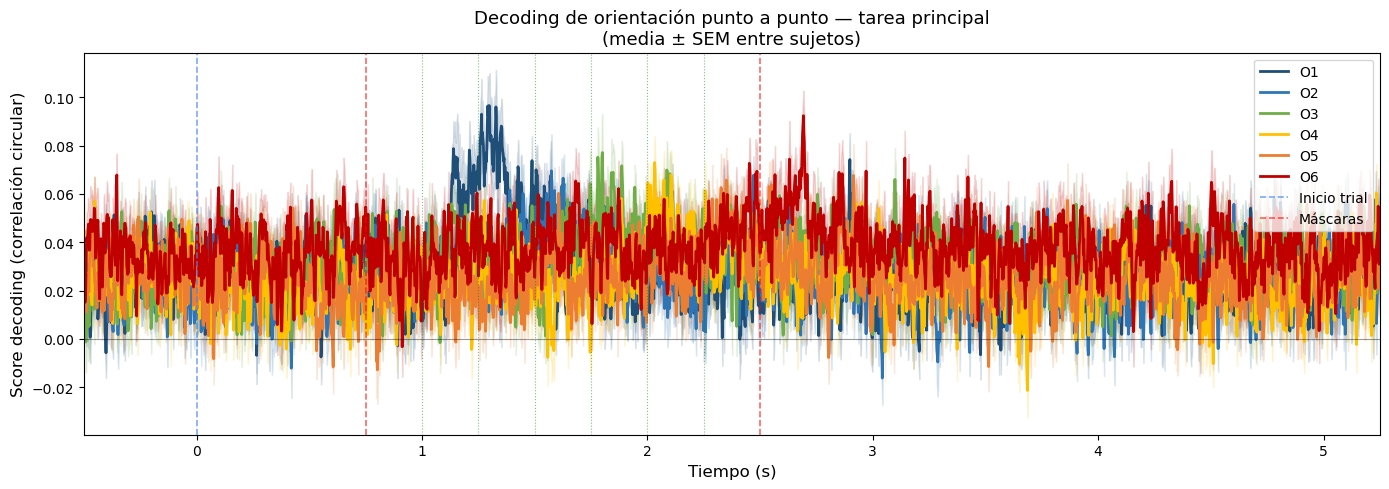

In [12]:
# ── Parámetros ────────────────────────────────────────────────────────────────
n_folds   = 5
n_stim    = 6
stim_cols = ['o1','o2','o3','o4','o5','o6']
bins_ori  = np.array([0, np.pi/4, np.pi/2, 3*np.pi/4])
time      = all_main_epochs[0].times
n_time    = len(time)

# Resultado final: (n_sujetos × n_estímulos × n_timepoints)
scorer_all_subjs = np.zeros((nSubj, n_stim, n_time))
all_preds        = {}  # guardamos predicciones para reutilizar en 7.4

t_start = tm.time()

for isubj in range(nSubj):
    print(f'\n── Sujeto {subjs_ok[isubj]} ({isubj+1}/{nSubj}) ──')
    
    Y        = all_main_rawdata[isubj]['epoch_dat']
    metadata = all_main_rawdata[isubj]['metadata'].reset_index(drop=True)
    all_preds[isubj] = {}

    for i_stim, col in enumerate(stim_cols):
        phi        = np.array(metadata[col], dtype=float)
        phi_binned = np.digitize(phi % np.pi, bins_ori)
        folds      = create_folds(phi_binned, n_folds)
        preds_all  = np.full((Y.shape[0], n_time), np.nan)
        clf        = AngularRegression(clf=LinearSVR(max_iter=5000, C=0.1))

        for it in range(n_time):
            Ytime  = Y[:, :, it]
            scaler = StandardScaler().fit(Ytime)
            Ytime  = scaler.transform(Ytime)

            for fold in folds:
                train_ix = fold['train_index']
                test_ix  = fold['test_index']
                clf.fit(Ytime[train_ix], phi[train_ix])
                preds_all[test_ix, it] = clf.predict(Ytime[test_ix])

        for it in range(n_time):
            valid = ~np.isnan(preds_all[:, it])
            scorer_all_subjs[isubj, i_stim, it] = scorer_angle(
                phi[valid], preds_all[valid, it]
            )

        # Guardamos predicciones para reutilizar en 7.4
        all_preds[isubj][i_stim] = preds_all.copy()

        print(f'  O{i_stim+1} ✓', end='', flush=True)

    elapsed = (tm.time() - t_start) / 60
    print(f'  → {elapsed:.1f} min transcurridos')

print(f'\n✅ Decoding completado — shape resultado: {scorer_all_subjs.shape}')

# ── Guardar resultados ────────────────────────────────────────────────────────
import pickle

results = {
    'scorer_all_subjs': scorer_all_subjs,
    'all_preds':        all_preds,
    'time':             time,
    'subjs_ok':         subjs_ok,
    'stim_cols':        stim_cols,
}

save_path = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_main.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(results, f)

print(f'✅ Resultados guardados en: {save_path}')

# ── Plot ──────────────────────────────────────────────────────────────────────
scorer_mean = np.mean(scorer_all_subjs, axis=0)
scorer_sem  = np.std(scorer_all_subjs, axis=0) / np.sqrt(nSubj)

colors = ['#1f4e79', '#2e75b6', '#70ad47', '#ffc000', '#ed7d31', '#c00000']

fig, ax = plt.subplots(figsize=(14, 5))

for i_stim in range(n_stim):
    mean = scorer_mean[i_stim]
    sem  = scorer_sem[i_stim]
    ax.plot(time, mean, color=colors[i_stim], lw=2, label=f'O{i_stim+1}')
    ax.fill_between(time, mean - sem, mean + sem,
                    color=colors[i_stim], alpha=0.15)

ax.axvline(0,                color='#4488EE', ls='--', lw=1.2, alpha=0.7, label='Inicio trial')
ax.axvline(0.75,             color='red',     ls='--', lw=1.2, alpha=0.6, label='Máscaras')
ax.axvline(0.75 + 0.25 * 7, color='red',     ls='--', lw=1.2, alpha=0.6)
for i_stim in range(6):
    ax.axvline(0.75 + 0.25 * (i_stim + 1), color='green', ls=':', lw=0.8, alpha=0.5)

ax.axhline(0, color='black', ls='-', lw=0.8, alpha=0.4)
ax.set_xlabel('Tiempo (s)', fontsize=12)
ax.set_ylabel('Score decoding (correlación circular)', fontsize=12)
ax.set_title('Decoding de orientación punto a punto — tarea principal\n'
             '(media ± SEM entre sujetos)', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.set_xlim([time[0], time[-1]])
plt.tight_layout()
plt.show()

### 7.4 Plot — curvas separadas por nrep (¿baja la amplitud con las repeticiones?)

In [13]:
# ── Decoding por nrep — REUTILIZANDO predicciones de 7.2 ─────────────────────
nreps       = [0, 1, 2]
colors_nrep = ['#1a3a6e', '#2e7bbf', '#7ec8e3']

# shape: (n_nreps × n_sujetos × n_estímulos × n_timepoints)
scorer_nrep = np.zeros((len(nreps), nSubj, n_stim, n_time))

for isubj in range(nSubj):
    metadata = all_main_rawdata[isubj]['metadata'].reset_index(drop=True)
    
    for i_stim, col in enumerate(stim_cols):
        phi       = np.array(metadata[col], dtype=float)
        preds     = all_preds[isubj][i_stim]  # (n_trials × n_time) ya calculado
        
        for i_nrep, nrep in enumerate(nreps):
            idx_nrep = metadata[metadata['nrep'] == nrep].index.tolist()
            if len(idx_nrep) == 0:
                continue
            
            phi_nrep   = phi[idx_nrep]
            preds_nrep = preds[idx_nrep]
            
            for it in range(n_time):
                valid = ~np.isnan(preds_nrep[:, it])
                scorer_nrep[i_nrep, isubj, i_stim, it] = scorer_angle(
                    phi_nrep[valid], preds_nrep[valid, it]
                )

print('✅ Decoding por nrep completado — shape:', scorer_nrep.shape)

✅ Decoding por nrep completado — shape: (3, 25, 6, 2876)


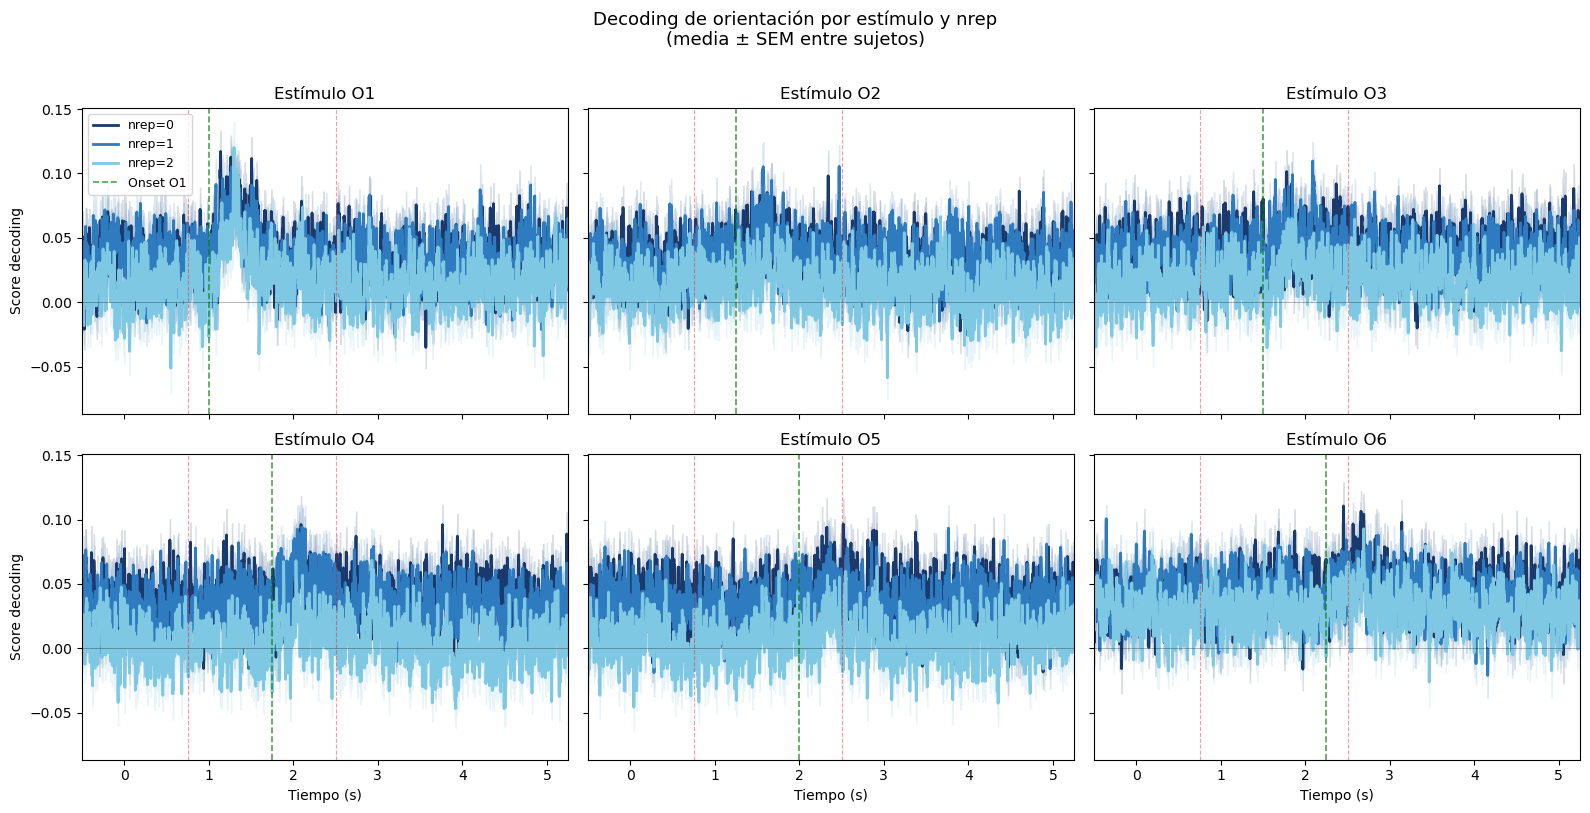

In [14]:
# ── Plot por nrep — un subplot por estímulo ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i_stim in range(n_stim):
    ax = axes[i_stim]
    
    for i_nrep, nrep in enumerate(nreps):
        mean = np.mean(scorer_nrep[i_nrep, :, i_stim, :], axis=0)
        sem  = np.std(scorer_nrep[i_nrep, :, i_stim, :], axis=0) / np.sqrt(nSubj)
        ax.plot(time, mean, color=colors_nrep[i_nrep], lw=2, label=f'nrep={nrep}')
        ax.fill_between(time, mean - sem, mean + sem,
                        color=colors_nrep[i_nrep], alpha=0.15)
    
    # Onset del estímulo correspondiente
    t_onset = 0.75 + 0.25 * (i_stim + 1)
    ax.axvline(t_onset, color='green', ls='--', lw=1.2, alpha=0.7, label=f'Onset O{i_stim+1}')
    ax.axvline(0.75,             color='red', ls='--', lw=0.8, alpha=0.4)
    ax.axvline(0.75 + 0.25 * 7, color='red', ls='--', lw=0.8, alpha=0.4)
    ax.axhline(0, color='black', ls='-', lw=0.5, alpha=0.4)
    
    ax.set_title(f'Estímulo O{i_stim+1}', fontsize=12)
    ax.set_xlim([time[0], time[-1]])
    if i_stim in [0, 3]:
        ax.set_ylabel('Score decoding', fontsize=10)
    if i_stim in [3, 4, 5]:
        ax.set_xlabel('Tiempo (s)', fontsize=10)
    if i_stim == 0:
        ax.legend(fontsize=9)

fig.suptitle('Decoding de orientación por estímulo y nrep\n'
             '(media ± SEM entre sujetos)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
import pickle

results = {
    'scorer_all_subjs': scorer_all_subjs,   # (nSubj × 6 × 2876)
    'scorer_nrep':      scorer_nrep,        # (3 × nSubj × 6 × 2876)
    'all_preds':        all_preds,          # predicciones por sujeto y estímulo
    'time':             time,
    'subjs_ok':         subjs_ok,
    'stim_cols':        stim_cols,
}

save_path = '/Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_main.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(results, f)

print(f'✅ Resultados finales guardados en: {save_path}')

✅ Resultados finales guardados en: /Users/martu/Documents/TFG_MARTINA/dataset/preprocessament/EEG/decoding_results_main.pkl


: 